In [1]:
!pip install datasets tqdm


In [2]:
from datasets import load_dataset
import json
import os
from tqdm import tqdm

def build_big_train(save_path="big_train.jsonl"):
    # 1. Load SQuAD 2.0 dataset
    ds = load_dataset("squad_v2")

    train = ds["train"]
    val = ds["validation"]

    print("Train size:", len(train))       # ~130,319
    print("Validation size:", len(val))   # ~11,873

    # 2. Combine train + validation
    combined = list(train) + list(val)

    # 3. Save in JSONL format
    with open(save_path, "w", encoding="utf-8") as f:
        for ex in tqdm(combined, desc="Saving big_train"):
            record = {
                "id": ex["id"],
                "title": ex.get("title", ""),
                "context": ex["context"],
                "question": ex["question"],
                "answers": ex["answers"]
            }
            f.write(json.dumps(record) + "\n")

    print(f"\n✅ Saved combined dataset to {save_path}")
    print("   Total samples:", len(combined))

# Run this function
build_big_train()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

squad_v2/train-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

squad_v2/validation-00000-of-00001.parqu(…):   0%|          | 0.00/1.35M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]

Train size: 130319
Validation size: 11873


Saving big_train: 100%|██████████| 142192/142192 [00:01<00:00, 112731.19it/s]


✅ Saved combined dataset to big_train.jsonl
   Total samples: 142192


In [4]:
import json

with open("big_train.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 5: break
        sample = json.loads(line)
        print(f"Q{i+1}: {sample['question']}")


Q1: When did Beyonce start becoming popular?
Q2: What areas did Beyonce compete in when she was growing up?
Q3: When did Beyonce leave Destiny's Child and become a solo singer?
Q4: In what city and state did Beyonce  grow up? 
Q5: In which decade did Beyonce become famous?


In [5]:
!pip install transformers torch datasets


In [7]:
!pip install transformers torch datasets

import torch
import time
import json
import re, string
from collections import Counter
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline
from tqdm import tqdm

# ---------------------------
# Helper functions (EM & F1)
# ---------------------------
def normalize_answer(s):
    """Lower text, remove punctuation, articles and extra whitespace."""
    def remove_articles(text): return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text): return ' '.join(text.split())
    def remove_punc(text): return ''.join(ch for ch in set(string.punctuation))
    def lower(text): return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def f1_score(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    if not pred_tokens and not gt_tokens:
        return 1.0
    if not pred_tokens or not gt_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(gt_tokens)
    return (2 * precision * recall) / (precision + recall)

def exact_match_score(prediction, ground_truth):
    return float(normalize_answer(prediction) == normalize_answer(ground_truth))

# ---------------------------
# Model Setup
# ---------------------------
MODEL_NAMES = [
    "deepset/roberta-base-squad2",
    "distilbert/distilbert-base-uncased-distilled-squad",
    "bert-large-uncased-whole-word-masking-finetuned-squad"
]

def load_models(model_names=MODEL_NAMES):
    models = {}
    for name in model_names:
        print(f"Loading {name} ...")
        tokenizer = AutoTokenizer.from_pretrained(name)
        model = AutoModelForQuestionAnswering.from_pretrained(name).to("cuda")
        models[name] = pipeline("question-answering", model=model, tokenizer=tokenizer, device=0)
    return models

# ---------------------------
# Baseline Evaluation
# ---------------------------
def evaluate_baseline(models, data_path="big_train.jsonl", sample_size=100):
    # Load a few samples for baseline
    samples = []
    with open(data_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= sample_size: break
            samples.append(json.loads(line))

    results = {name: {"em": [], "f1": [], "latency": [], "tokens": []} for name in models}

    for name, pipe in models.items():
        print(f"\n🔹 Evaluating {name}")
        for ex in tqdm(samples, desc=f"Running {name}"):
            question = ex["question"]
            context = ex["context"]
            answers = ex["answers"]["text"]

            start = time.time()
            out = pipe(question=question, context=context)
            latency = time.time() - start

            pred = out["answer"]
            gold = answers[0] if len(answers) > 0 else ""

            em = exact_match_score(pred, gold)
            f1 = f1_score(pred, gold)
            token_count = len(pipe.tokenizer.tokenize(question + context))

            results[name]["em"].append(em)
            results[name]["f1"].append(f1)
            results[name]["latency"].append(latency)
            results[name]["tokens"].append(token_count)

        em_avg = sum(results[name]["em"]) / len(results[name]["em"])
        f1_avg = sum(results[name]["f1"]) / len(results[name]["f1"])
        latency_avg = sum(results[name]["latency"]) / len(results[name]["latency"])
        tokens_avg = sum(results[name]["tokens"]) / len(results[name]["tokens"])

        print(f"✅ {name} — EM: {em_avg:.3f}, F1: {f1_avg:.3f}, "
              f"Latency: {latency_avg:.3f}s, Avg Tokens: {tokens_avg:.1f}")

    return results

# ---------------------------
# Run Baseline
# ---------------------------
models = load_models()
baseline_results = evaluate_baseline(models, "big_train.jsonl", sample_size=100)


Loading deepset/roberta-base-squad2 ...


tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

✅ deepset/roberta-base-squad2 — EM: 1.000, F1: 1.000, Latency: 0.023s, Avg Tokens: 227.9

🔹 Evaluating distilbert/distilbert-base-uncased-distilled-squad


Running distilbert/distilbert-base-uncased-distilled-squad: 100%|██████████| 100/100 [00:01<00:00, 97.29it/s]


✅ distilbert/distilbert-base-uncased-distilled-squad — EM: 1.000, F1: 1.000, Latency: 0.009s, Avg Tokens: 224.6

🔹 Evaluating bert-large-uncased-whole-word-masking-finetuned-squad


Running bert-large-uncased-whole-word-masking-finetuned-squad: 100%|██████████| 100/100 [00:04<00:00, 20.53it/s]

✅ bert-large-uncased-whole-word-masking-finetuned-squad — EM: 1.000, F1: 1.000, Latency: 0.047s, Avg Tokens: 224.6


In [8]:
# Phase 3: Prompt Variant Generation (5000 samples)
import json
import random
import os
import re
from tqdm import tqdm

random.seed(42)  # reproducibility

BIG_TRAIN_PATH = "big_train.jsonl"
OUT_VARIANTS_PATH = "data/prompt_variants_5k.jsonl"  # output file

# -------------------------
# Simple sentence splitter
# -------------------------
def split_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sentences if s.strip()]

# -------------------------
# Few-shot examples
# -------------------------
def build_few_shot_examples(all_samples, k=3):
    candidates = [s for s in all_samples if s.get("answers", {}).get("text")]
    if len(candidates) <= k:
        chosen = candidates
    else:
        chosen = random.sample(candidates, k)
    formatted = []
    for ex in chosen:
        q = ex["question"].strip()
        a = ex["answers"]["text"][0].strip() if ex["answers"]["text"] else "NoAnswer"
        formatted.append(f"Q: {q}\nA: {a}")
    return "\n\n".join(formatted)

# -------------------------
# Prompt templates
# -------------------------
def baseline_prompt(question, context):
    return f"Context:\n{context}\n\nQuestion: {question}\nAnswer:"

def explicit_instruction_prompt(question, context):
    inst = ("Read the context and provide a concise answer to the question. "
            "If the question cannot be answered from the context, reply with 'No Answer'.")
    return f"{inst}\n\nContext:\n{context}\n\nQuestion: {question}\nAnswer:"

def context_highlight_prompt(question, context, gold_answers):
    sentences = split_sentences(context)
    if gold_answers:
        gold = gold_answers[0].strip()
        highlighted = []
        found = False
        for s in sentences:
            if gold.lower() in s.lower():
                highlighted.append(f"[HIGHLIGHT]{s}[/HIGHLIGHT]")
                found = True
            else:
                highlighted.append(s)
        if not found and sentences:
            highlighted[0] = f"[HIGHLIGHT]{sentences[0]}[/HIGHLIGHT]"
        highlighted_context = " ".join(highlighted)
        return (f"Context (important parts are marked with [HIGHLIGHT]...[/HIGHLIGHT]):\n"
                f"{highlighted_context}\n\nQuestion: {question}\nAnswer:")
    else:
        inst = "This question might be unanswerable based on the provided context. If unanswerable, respond with 'No Answer'."
        return f"{inst}\n\nContext:\n{context}\n\nQuestion: {question}\nAnswer:"

def few_shot_prompt(question, context, few_shot_examples):
    prefix = ("Below are a few examples showing how to answer questions from a context.\n\n"
             f"{few_shot_examples}\n\nNow answer the next one concisely.\n\n")
    return f"{prefix}Context:\n{context}\n\nQuestion: {question}\nAnswer:"

# -------------------------
# Load and generate
# -------------------------
def load_big_train(path=BIG_TRAIN_PATH, max_samples=None):
    samples = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if max_samples and i >= max_samples: break
            samples.append(json.loads(line))
    return samples

def generate_and_save_variants(all_samples, out_path, sample_limit=5000):
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    few_shot_cache = build_few_shot_examples(all_samples, k=3)

    total = 0
    with open(out_path, "w", encoding="utf-8") as fout:
        for ex in tqdm(all_samples[:sample_limit], desc="Generating variants"):
            total += 1
            q = ex["question"].strip()
            ctx = ex["context"].strip()
            golds = ex.get("answers", {}).get("text", [])

            variants = {
                "baseline": baseline_prompt(q, ctx),
                "explicit_instruction": explicit_instruction_prompt(q, ctx),
                "context_highlight": context_highlight_prompt(q, ctx, golds),
                "few_shot_3": few_shot_prompt(q, ctx, few_shot_cache)
            }

            out_record = {
                "id": ex["id"],
                "question": q,
                "context": ctx,
                "gold_answers": golds,
                "variants": variants
            }
            fout.write(json.dumps(out_record) + "\n")
    print(f"\n✅ Saved {total} prompt-variant records to {out_path}")

# -------------------------
# Preview function
# -------------------------
def preview_variants(out_path, i=0):
    with open(out_path, "r", encoding="utf-8") as f:
        for idx, line in enumerate(f):
            if idx == i:
                rec = json.loads(line)
                print("ID:", rec["id"])
                print("Question:", rec["question"])
                print("Gold:", rec["gold_answers"])
                print("\n--- Variants ---\n")
                for k, v in rec["variants"].items():
                    print(f"== {k} ==\n{v}\n")
                return
    print("Index out of range or file missing.")

# -------------------------
# Run
# -------------------------
if __name__ == "__main__":
    print("Loading big train...")
    samples = load_big_train(BIG_TRAIN_PATH)
    generate_and_save_variants(samples, OUT_VARIANTS_PATH, sample_limit=5000)
    print("\nPreviewing first sample variants:")
    preview_variants(OUT_VARIANTS_PATH, i=0)


Loading big train...


Generating variants: 100%|██████████| 5000/5000 [00:00<00:00, 11999.08it/s]


✅ Saved 5000 prompt-variant records to data/prompt_variants_5k.jsonl

Previewing first sample variants:
ID: 56be85543aeaaa14008c9063
Question: When did Beyonce start becoming popular?
Gold: ['in the late 1990s']

--- Variants ---

== baseline ==
Context:
Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in various singing and dancing competitions as a child, and rose to fame in the late 1990s as lead singer of R&B girl-group Destiny's Child. Managed by her father, Mathew Knowles, the group became one of the world's best-selling girl groups of all time. Their hiatus saw the release of Beyoncé's debut album, Dangerously in Love (2003), which established her as a solo artist worldwide, earned five Grammy Awards and featured the Billboard Hot 100 number-one singles "Crazy in Love" and "Baby Boy".

Question: When did Beyonce start becoming popula

In [26]:
# Phase 4: Multi-Model Evaluation Loop (Colab-ready, Corrected for variants)

import json
import time
import torch
import pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline
import re, string
from collections import Counter

# ---------------------------
# Helper functions
# ---------------------------
def normalize_answer(s):
    def remove_articles(text): return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text): return ' '.join(text.split())
    def remove_punc(text): return ''.join(ch for ch in text if ch not in set(string.punctuation))
    def lower(text): return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def f1_score(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    if not pred_tokens and not gt_tokens:
        return 1.0
    if not pred_tokens or not gt_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(gt_tokens)
    return (2 * precision * recall) / (precision + recall)

def exact_match_score(prediction, ground_truth):
    return float(normalize_answer(prediction) == normalize_answer(ground_truth))

# truncate very long question prompts to avoid tokenizer crash
def safe_truncate(text, tokenizer, max_tokens=96):
    tokens = tokenizer.tokenize(text)
    if len(tokens) > max_tokens:
        tokens = tokens[:max_tokens]
    return tokenizer.convert_tokens_to_string(tokens)

# ---------------------------
# Models
# ---------------------------
MODEL_NAMES = [
    "deepset/roberta-base-squad2",
    "distilbert/distilbert-base-uncased-distilled-squad",
    "bert-large-uncased-whole-word-masking-finetuned-squad"
]

def load_models(model_names=MODEL_NAMES):
    models = {}
    for name in model_names:
        print(f"Loading {name} ...")
        tokenizer = AutoTokenizer.from_pretrained(name)
        model = AutoModelForQuestionAnswering.from_pretrained(name).to("cuda")
        models[name] = pipeline(
            "question-answering",
            model=model,
            tokenizer=tokenizer,
            device=0
        )
    return models

# ---------------------------
# Evaluation
# ---------------------------
def evaluate_variants(models, data_path="data/prompt_variants_5k.jsonl", sample_limit=500):
    samples = []
    with open(data_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= sample_limit: break
            samples.append(json.loads(line))

    rows = []
    for model_name, pipe in models.items():
        print(f"\n🔹 Evaluating {model_name}")
        for ex in tqdm(samples, desc=f"Running {model_name}"):
            ctx = ex["context"]
            golds = ex["gold_answers"]
            gold = golds[0] if golds else ""

            for variant_name, prompt in ex["variants"].items():
                try:
                    # -------------------
                    # Variant-specific mapping
                    # -------------------
                    if variant_name == "baseline":
                        q_input = prompt
                        c_input = ctx
                    elif variant_name == "explicit_instruction":
                        q_input = prompt
                        c_input = ctx
                    elif variant_name == "context_highlight":
                        q_input = ex["question"]        # keep original question
                        c_input = prompt                 # highlighted context
                    elif variant_name == "few_shot_3":
                        q_input = ex["question"]         # clean final question
                        c_input = prompt + "\n\n" + ctx  # few-shot examples in context
                    else:
                        q_input, c_input = prompt, ctx

                    safe_q = safe_truncate(q_input, pipe.tokenizer, max_tokens=96)
                    start = time.time()
                    out = pipe(question=safe_q, context=c_input)
                    latency = time.time() - start

                    pred = out["answer"]
                    em = exact_match_score(pred, gold)
                    f1 = f1_score(pred, gold)
                    token_count = len(pipe.tokenizer.tokenize(safe_q + c_input))

                    rows.append({
                        "model": model_name,
                        "variant": variant_name,
                        "em": em,
                        "f1": f1,
                        "latency": latency,
                        "tokens": token_count
                    })
                except Exception as e:
                    print(f"⚠️ Skipped {model_name}, {variant_name}: {e}")
    return pd.DataFrame(rows)

# ---------------------------
# Run
# ---------------------------
if __name__ == "__main__":
    models = load_models()
    df_results = evaluate_variants(models, "data/prompt_variants_5k.jsonl", sample_limit=500)

    # Save results
    df_results.to_csv("phase4_results_fixed_variants_500.csv", index=False)
    print("\n✅ Results saved to phase4_results_fixed_variants_500.csv")

    # Quick summary
    summary = df_results.groupby(["model", "variant"]).mean()[["em","f1","latency","tokens"]]
    print("\n=== Summary (averages over 500 samples) ===\n")
    print(summary)


Loading deepset/roberta-base-squad2 ...


Device set to use cuda:0


Loading distilbert/distilbert-base-uncased-distilled-squad ...


Device set to use cuda:0


Loading bert-large-uncased-whole-word-masking-finetuned-squad ...


...


🔹 Evaluating distilbert/distilbert-base-uncased-distilled-squad


Running distilbert/distilbert-base-uncased-distilled-squad:   3%|▎         | 14/500 [00:00<00:29, 16.72it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (574 > 512). Running this sequence through the model will result in indexing errors
Running distilbert/distilbert-base-uncased-distilled-squad: 100%|██████████| 500/500 [00:35<00:00, 14.27it/s]



🔹 Evaluating bert-large-uncased-whole-word-masking-finetuned-squad


Running bert-large-uncased-whole-word-masking-finetuned-squad:   3%|▎         | 15/500 [00:04<02:29,  3.24it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (574 > 512). Running this sequence through the model will result in indexing errors
Running bert-large-uncased-whole-word-masking-finetuned-squad: 100%|██████████| 500/500 [02:55<00:00,  2.85it/s]


✅ Results saved to phase4_results_fixed_variants_500.csv

=== Summary (averages over 500 samples) ===

                                                                            em  \
model                                              variant                       
bert-large-uncased-whole-word-masking-finetuned... baseline              0.108   
                                                   context_highlight     0.848   
                                                   explicit_instruction  0.036   
                                                   few_shot_3            0.812   
deepset/roberta-base-squad2                        baseline              0.062   
                                                   context_highlight     0.804   
                                                   explicit_instruction  0.026   
                                                   few_shot_3            0.788   
distilbert/distilbert-base-uncased-distilled-squad baseline              0.0


=== Average Metrics by Model & Variant ===

                                                                            em  \
model                                              variant                       
bert-large-uncased-whole-word-masking-finetuned... baseline              0.108   
                                                   context_highlight     0.848   
                                                   explicit_instruction  0.036   
                                                   few_shot_3            0.812   
deepset/roberta-base-squad2                        baseline              0.062   
                                                   context_highlight     0.804   
                                                   explicit_instruction  0.026   
                                                   few_shot_3            0.788   
distilbert/distilbert-base-uncased-distilled-squad baseline              0.034   
                                                   co

/tmp/ipython-input-3990522552.py:41: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df, x="variant", y="f1", hue="model", ci="sd")


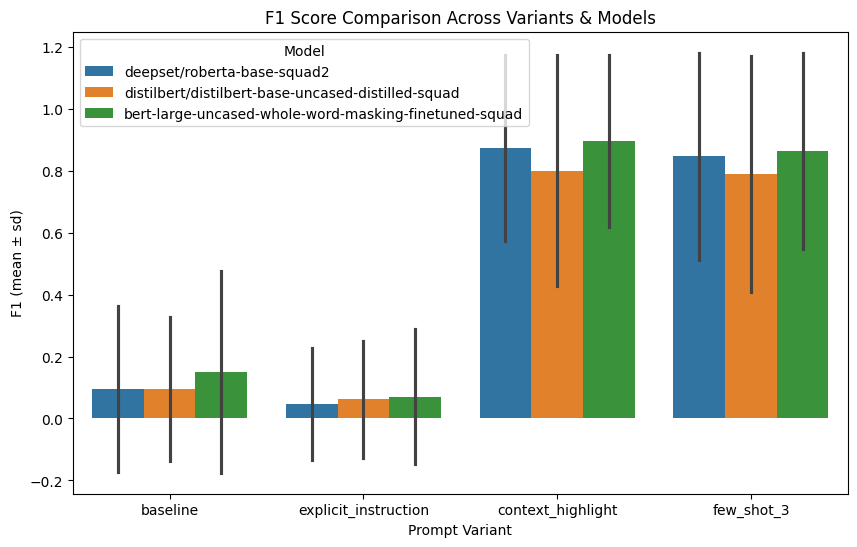

/tmp/ipython-input-3990522552.py:49: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df, x="variant", y="latency", hue="model", ci="sd")


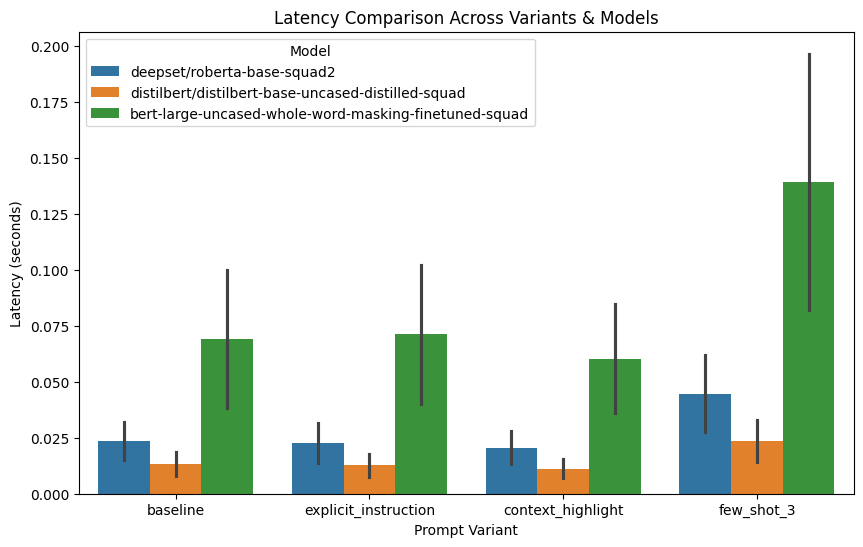

In [27]:
# Phase 5: Statistical Feedback & Prompt Refinement
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, f_oneway

# Load results from Phase 4
df = pd.read_csv("/content/phase4_results_fixed_variants_500.csv")   # if you ran 5000, load that file instead

# ---------------------------
# 1. Aggregate performance
# ---------------------------
summary = df.groupby(["model","variant"]).mean()[["em","f1","latency","tokens"]]
print("\n=== Average Metrics by Model & Variant ===\n")
print(summary)

# ---------------------------
# 2. Compare variants statistically
# ---------------------------
variants = df["variant"].unique()
print("\n=== Paired t-test results (F1) ===\n")
for i in range(len(variants)):
    for j in range(i+1, len(variants)):
        v1, v2 = variants[i], variants[j]
        scores1 = df[df["variant"]==v1]["f1"].values
        scores2 = df[df["variant"]==v2]["f1"].values
        t,p = ttest_rel(scores1, scores2)
        print(f"{v1} vs {v2} -> t={t:.3f}, p={p:.4f}")

# ---------------------------
# 3. ANOVA across all variants
# ---------------------------
anova = f_oneway(*[df[df["variant"]==v]["f1"].values for v in variants])
print("\n=== ANOVA on F1 across all variants ===\n")
print(anova)

# ---------------------------
# 4. Plot comparison
# ---------------------------
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="variant", y="f1", hue="model", ci="sd")
plt.title("F1 Score Comparison Across Variants & Models")
plt.ylabel("F1 (mean ± sd)")
plt.xlabel("Prompt Variant")
plt.legend(title="Model")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="variant", y="latency", hue="model", ci="sd")
plt.title("Latency Comparison Across Variants & Models")
plt.ylabel("Latency (seconds)")
plt.xlabel("Prompt Variant")
plt.legend(title="Model")
plt.show()



=== Variant Summary (mean over all models) ===

                variant        em        f1   latency      tokens
0              baseline  0.068000  0.113164  0.035263  290.490667
1     context_highlight  0.796667  0.856798  0.030613  254.432000
2  explicit_instruction  0.028000  0.059155  0.035440  291.572000
3            few_shot_3  0.775333  0.833722  0.069223  500.953333


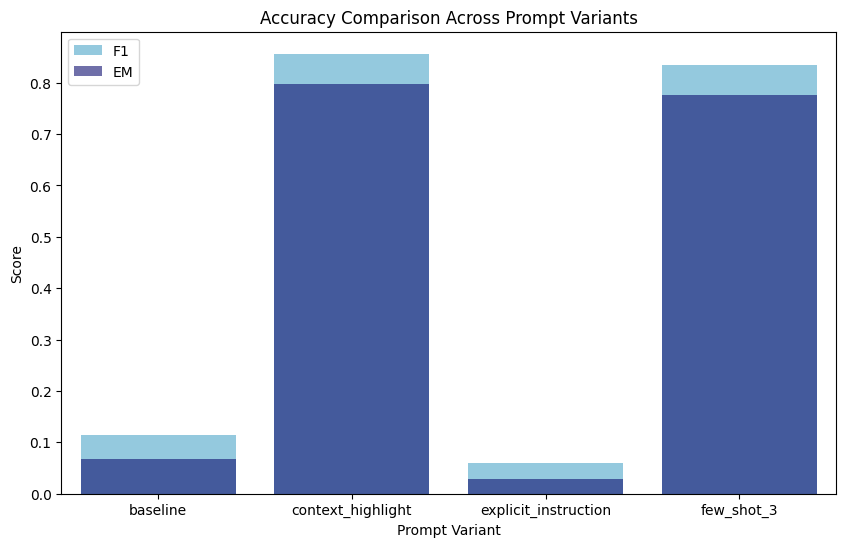

/tmp/ipython-input-2222481573.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=variant_summary, x="variant", y="latency", palette="viridis")


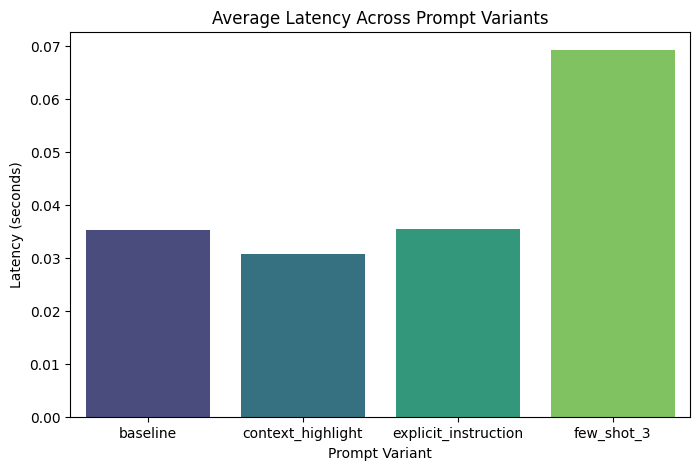

/tmp/ipython-input-2222481573.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=variant_summary, x="variant", y="tokens", palette="magma")


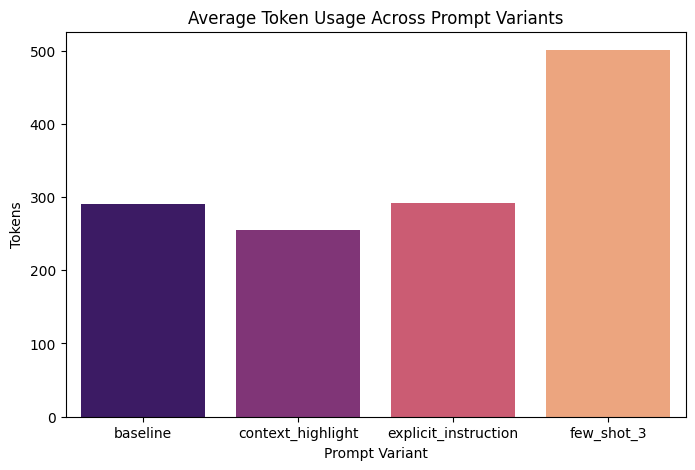

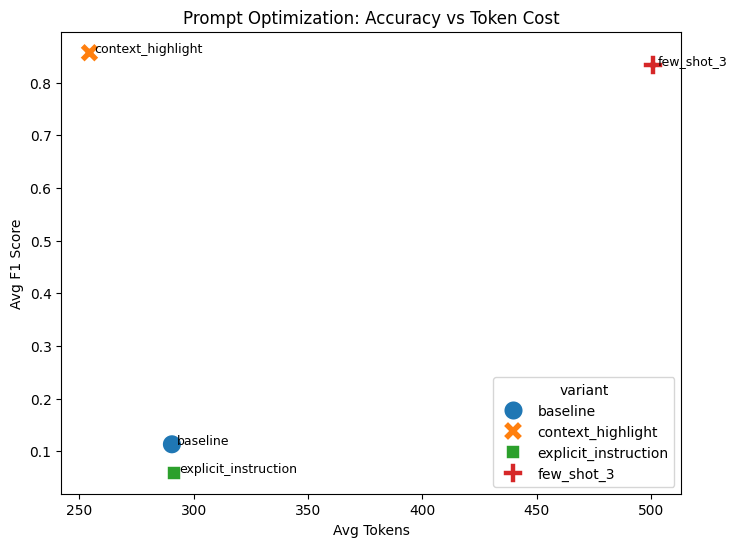

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load results (500 or 5000 depending on your run)
df = pd.read_csv("/content/phase4_results_fixed_variants_500.csv")   # change file if needed

# ---------------------------
# Keep only numeric columns for averaging
# ---------------------------
variant_summary = df.groupby("variant")[["em","f1","latency","tokens"]].mean().reset_index()

print("\n=== Variant Summary (mean over all models) ===\n")
print(variant_summary)

# ---------------------------
# Plot 1: Accuracy (F1 & EM)
# ---------------------------
plt.figure(figsize=(10,6))
sns.barplot(data=variant_summary, x="variant", y="f1", color="skyblue", label="F1")
sns.barplot(data=variant_summary, x="variant", y="em", color="navy", alpha=0.6, label="EM")
plt.title("Accuracy Comparison Across Prompt Variants")
plt.ylabel("Score")
plt.xlabel("Prompt Variant")
plt.legend()
plt.show()

# ---------------------------
# Plot 2: Efficiency (Latency)
# ---------------------------
plt.figure(figsize=(8,5))
sns.barplot(data=variant_summary, x="variant", y="latency", palette="viridis")
plt.title("Average Latency Across Prompt Variants")
plt.ylabel("Latency (seconds)")
plt.xlabel("Prompt Variant")
plt.show()

# ---------------------------
# Plot 3: Efficiency (Token usage)
# ---------------------------
plt.figure(figsize=(8,5))
sns.barplot(data=variant_summary, x="variant", y="tokens", palette="magma")
plt.title("Average Token Usage Across Prompt Variants")
plt.ylabel("Tokens")
plt.xlabel("Prompt Variant")
plt.show()

# ---------------------------
# Plot 4: Accuracy vs Token Cost (Tradeoff)
# ---------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=variant_summary,
    x="tokens", y="f1", hue="variant", s=200, style="variant"
)
for i,row in variant_summary.iterrows():
    plt.text(row["tokens"]+2, row["f1"], row["variant"], fontsize=9)
plt.title("Prompt Optimization: Accuracy vs Token Cost")
plt.xlabel("Avg Tokens")
plt.ylabel("Avg F1 Score")
plt.show()



=== Variant Summary (mean over all models) ===

                variant        em        f1   latency      tokens
0              baseline  0.068000  0.113164  0.035263  290.490667
1     context_highlight  0.796667  0.856798  0.030613  254.432000
2  explicit_instruction  0.028000  0.059155  0.035440  291.572000
3            few_shot_3  0.775333  0.833722  0.069223  500.953333


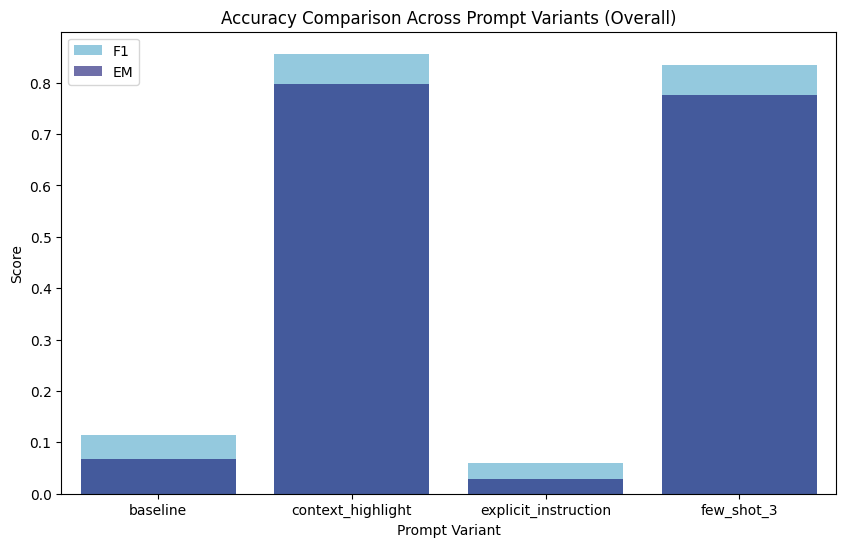

/tmp/ipython-input-2530411348.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=variant_summary, x="variant", y="latency", palette="viridis")


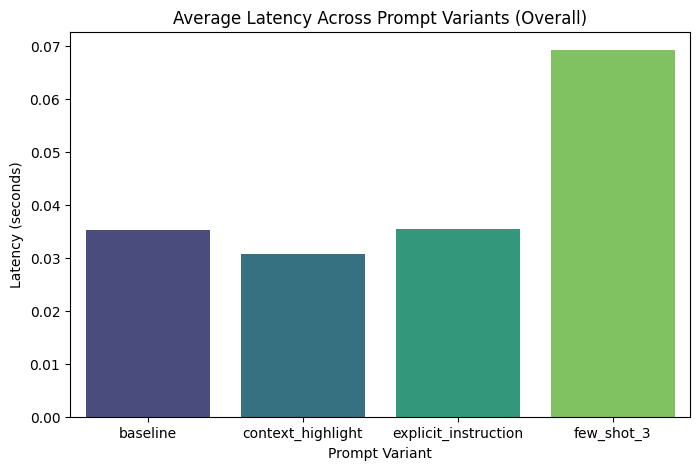

/tmp/ipython-input-2530411348.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=variant_summary, x="variant", y="tokens", palette="magma")


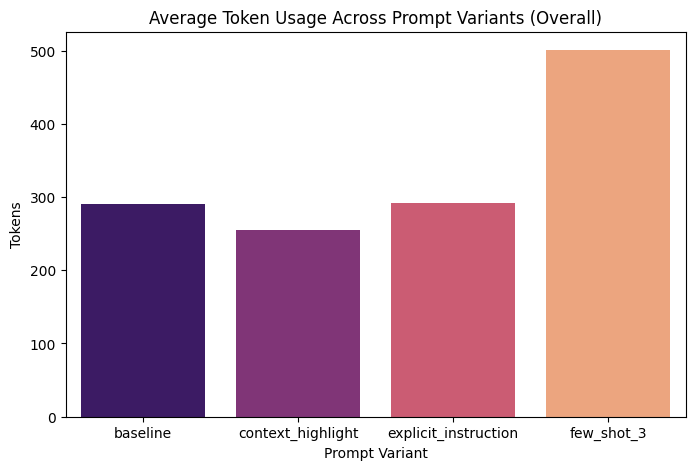

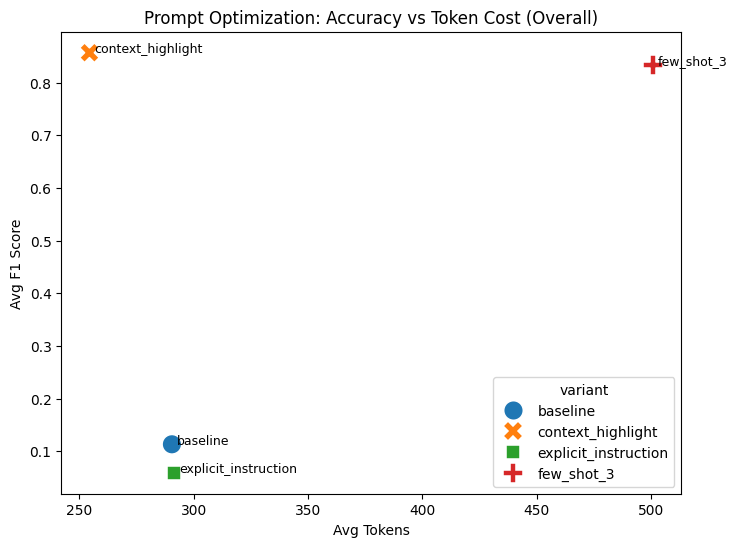


=== Per-Model Variant Summary ===

                                                model               variant  \
0   bert-large-uncased-whole-word-masking-finetune...              baseline   
1   bert-large-uncased-whole-word-masking-finetune...     context_highlight   
2   bert-large-uncased-whole-word-masking-finetune...  explicit_instruction   
3   bert-large-uncased-whole-word-masking-finetune...            few_shot_3   
4                         deepset/roberta-base-squad2              baseline   
5                         deepset/roberta-base-squad2     context_highlight   
6                         deepset/roberta-base-squad2  explicit_instruction   
7                         deepset/roberta-base-squad2            few_shot_3   
8   distilbert/distilbert-base-uncased-distilled-s...              baseline   
9   distilbert/distilbert-base-uncased-distilled-s...     context_highlight   
10  distilbert/distilbert-base-uncased-distilled-s...  explicit_instruction   
11  distilbert/d

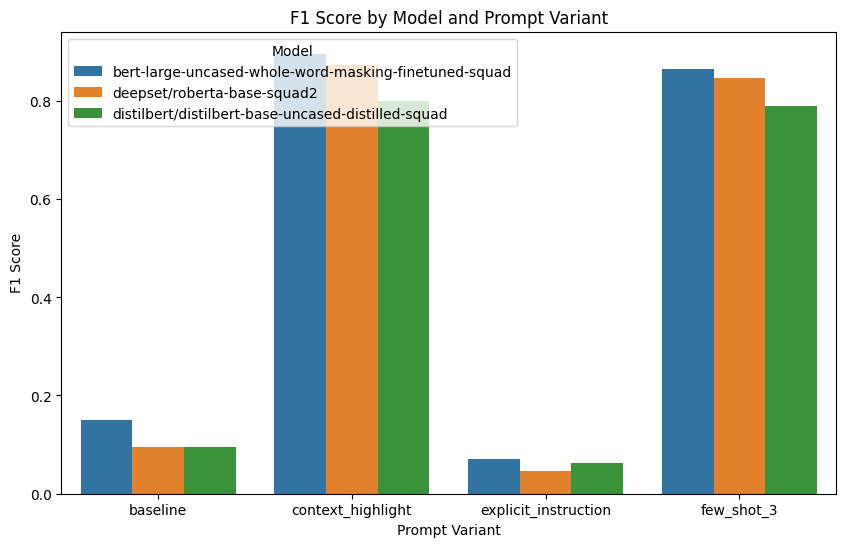

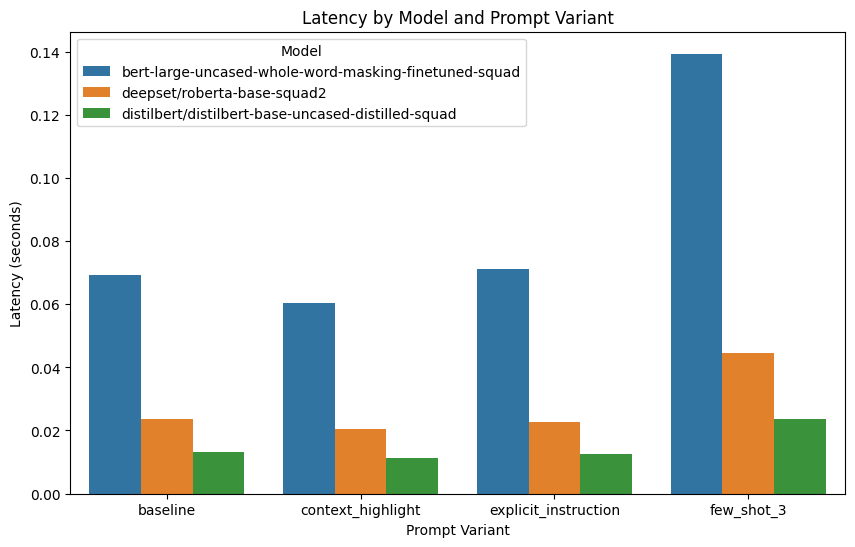

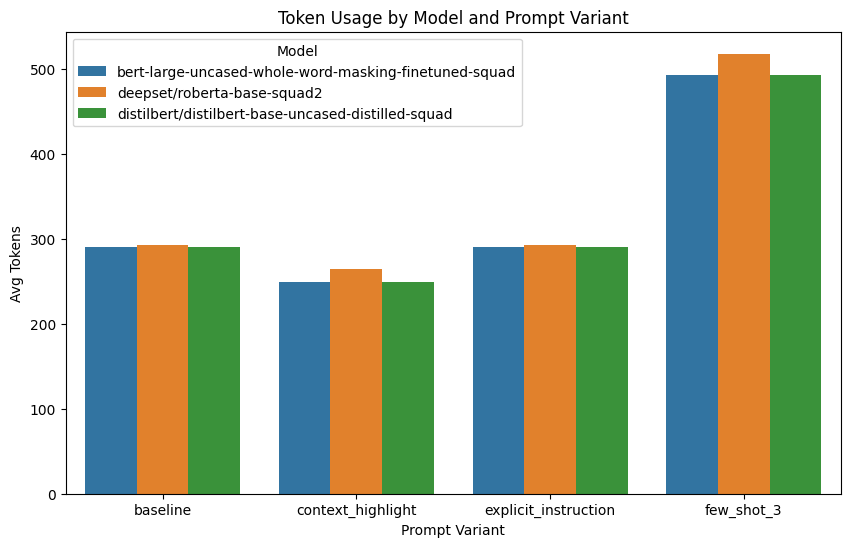

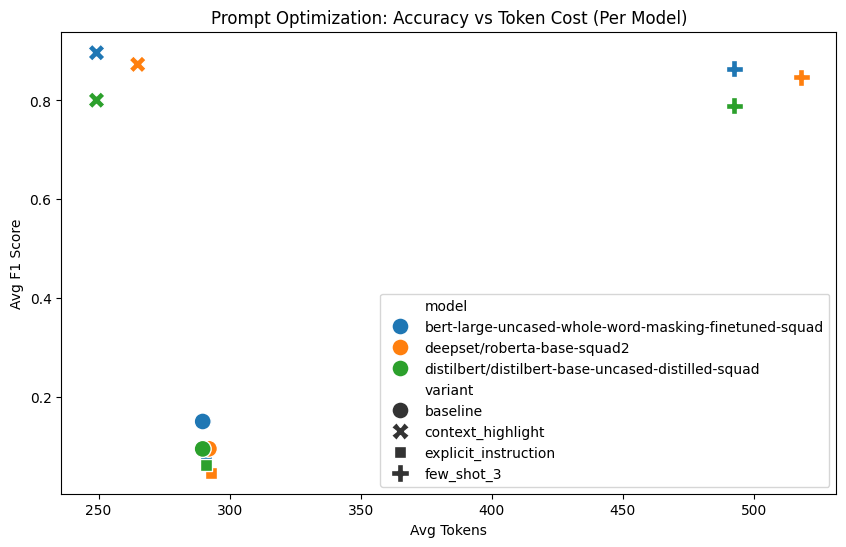

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your results file (500 or 5000 depending on your run)
df = pd.read_csv("/content/phase4_results_fixed_variants_500.csv")   # change if needed

# ---------------------------
# Overall averages by variant
# ---------------------------
variant_summary = df.groupby("variant")[["em","f1","latency","tokens"]].mean().reset_index()

print("\n=== Variant Summary (mean over all models) ===\n")
print(variant_summary)

# --- Plot 1: Accuracy (F1 & EM overall) ---
plt.figure(figsize=(10,6))
sns.barplot(data=variant_summary, x="variant", y="f1", color="skyblue", label="F1")
sns.barplot(data=variant_summary, x="variant", y="em", color="navy", alpha=0.6, label="EM")
plt.title("Accuracy Comparison Across Prompt Variants (Overall)")
plt.ylabel("Score")
plt.xlabel("Prompt Variant")
plt.legend()
plt.show()

# --- Plot 2: Latency overall ---
plt.figure(figsize=(8,5))
sns.barplot(data=variant_summary, x="variant", y="latency", palette="viridis")
plt.title("Average Latency Across Prompt Variants (Overall)")
plt.ylabel("Latency (seconds)")
plt.xlabel("Prompt Variant")
plt.show()

# --- Plot 3: Token usage overall ---
plt.figure(figsize=(8,5))
sns.barplot(data=variant_summary, x="variant", y="tokens", palette="magma")
plt.title("Average Token Usage Across Prompt Variants (Overall)")
plt.ylabel("Tokens")
plt.xlabel("Prompt Variant")
plt.show()

# --- Plot 4: Accuracy vs Token Cost overall ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=variant_summary,
    x="tokens", y="f1", hue="variant", s=200, style="variant"
)
for i,row in variant_summary.iterrows():
    plt.text(row["tokens"]+2, row["f1"], row["variant"], fontsize=9)
plt.title("Prompt Optimization: Accuracy vs Token Cost (Overall)")
plt.xlabel("Avg Tokens")
plt.ylabel("Avg F1 Score")
plt.show()

# ---------------------------
# Per-model summaries
# ---------------------------
model_variant_summary = df.groupby(["model","variant"])[["em","f1","latency","tokens"]].mean().reset_index()

print("\n=== Per-Model Variant Summary ===\n")
print(model_variant_summary)

# --- Plot 5: Per-Model F1 ---
plt.figure(figsize=(10,6))
sns.barplot(data=model_variant_summary, x="variant", y="f1", hue="model")
plt.title("F1 Score by Model and Prompt Variant")
plt.ylabel("F1 Score")
plt.xlabel("Prompt Variant")
plt.legend(title="Model")
plt.show()

# --- Plot 6: Per-Model Latency ---
plt.figure(figsize=(10,6))
sns.barplot(data=model_variant_summary, x="variant", y="latency", hue="model")
plt.title("Latency by Model and Prompt Variant")
plt.ylabel("Latency (seconds)")
plt.xlabel("Prompt Variant")
plt.legend(title="Model")
plt.show()

# --- Plot 7: Per-Model Token Usage ---
plt.figure(figsize=(10,6))
sns.barplot(data=model_variant_summary, x="variant", y="tokens", hue="model")
plt.title("Token Usage by Model and Prompt Variant")
plt.ylabel("Avg Tokens")
plt.xlabel("Prompt Variant")
plt.legend(title="Model")
plt.show()

# --- Plot 8: F1 vs Tokens (Per-Model Tradeoff) ---
plt.figure(figsize=(10,6))
sns.scatterplot(data=model_variant_summary, x="tokens", y="f1", hue="model", style="variant", s=150)
plt.title("Prompt Optimization: Accuracy vs Token Cost (Per Model)")
plt.xlabel("Avg Tokens")
plt.ylabel("Avg F1 Score")
plt.show()


In [30]:
import pandas as pd

# Load results
df = pd.read_csv("/content/phase4_results_fixed_variants_500.csv")   # change to your full results file if needed

# Aggregate metrics
model_variant_summary = df.groupby(["model","variant"])[["em","f1","latency","tokens"]].mean().reset_index()

# Extract baseline per model
baseline = model_variant_summary[model_variant_summary["variant"]=="baseline"]

# Find best variant (highest F1) per model
best_variants = model_variant_summary.loc[model_variant_summary.groupby("model")["f1"].idxmax()]

# Merge baseline vs best
comparison = baseline.merge(
    best_variants,
    on="model",
    suffixes=("_baseline","_best")
)

# Add improvement columns
comparison["f1_gain"] = comparison["f1_best"] - comparison["f1_baseline"]
comparison["em_gain"] = comparison["em_best"] - comparison["em_baseline"]
comparison["latency_change"] = comparison["latency_best"] - comparison["latency_baseline"]
comparison["token_change"] = comparison["tokens_best"] - comparison["tokens_baseline"]

print("\n=== Before vs After Optimization (Per Model) ===\n")
print(comparison[[
    "model",
    "variant_baseline","variant_best",
    "f1_baseline","f1_best","f1_gain",
    "em_baseline","em_best","em_gain",
    "latency_baseline","latency_best","latency_change",
    "tokens_baseline","tokens_best","token_change"
]])



=== Before vs After Optimization (Per Model) ===

                                               model variant_baseline  \
0  bert-large-uncased-whole-word-masking-finetune...         baseline   
1                        deepset/roberta-base-squad2         baseline   
2  distilbert/distilbert-base-uncased-distilled-s...         baseline   

        variant_best  f1_baseline   f1_best   f1_gain  em_baseline  em_best  \
0  context_highlight     0.150112  0.896711  0.746598        0.108    0.848   
1  context_highlight     0.094807  0.873111  0.778304        0.062    0.804   
2  context_highlight     0.094572  0.800571  0.705999        0.034    0.738   

   em_gain  latency_baseline  latency_best  latency_change  tokens_baseline  \
0    0.740          0.069115      0.060241       -0.008873          289.700   
1    0.742          0.023503      0.020464       -0.003039          292.072   
2    0.704          0.013172      0.011133       -0.002039          289.700   

   tokens_best  token_


=== Baseline vs Best Variant (Per Model) ===

                                               model variant_baseline  \
0  bert-large-uncased-whole-word-masking-finetune...         baseline   
1                        deepset/roberta-base-squad2         baseline   
2  distilbert/distilbert-base-uncased-distilled-s...         baseline   

        variant_best  f1_baseline   f1_best   f1_gain  em_baseline  em_best  \
0  context_highlight     0.150112  0.896711  0.746598        0.108    0.848   
1  context_highlight     0.094807  0.873111  0.778304        0.062    0.804   
2  context_highlight     0.094572  0.800571  0.705999        0.034    0.738   

   em_gain  
0    0.740  
1    0.742  
2    0.704  


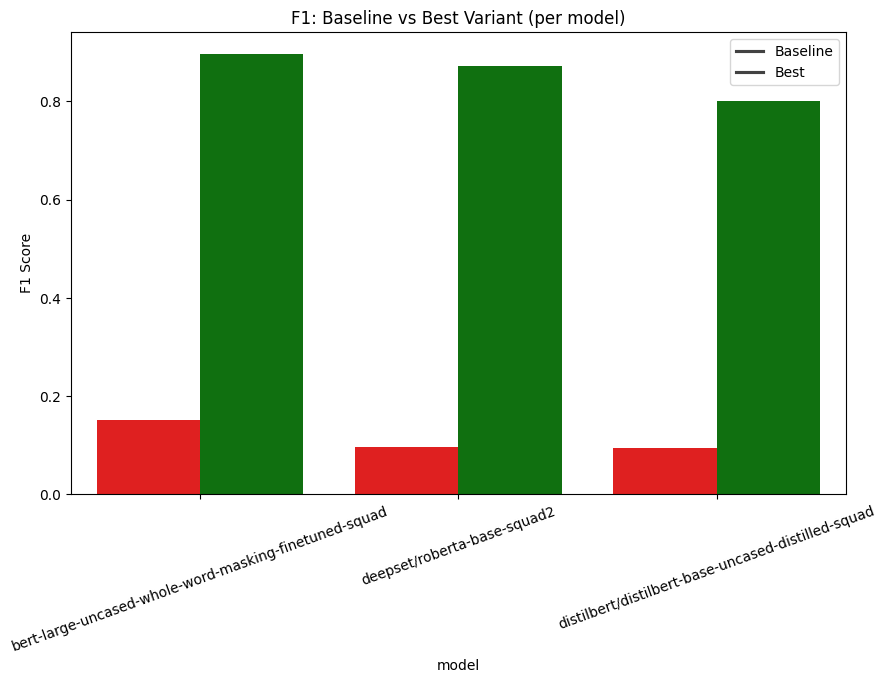

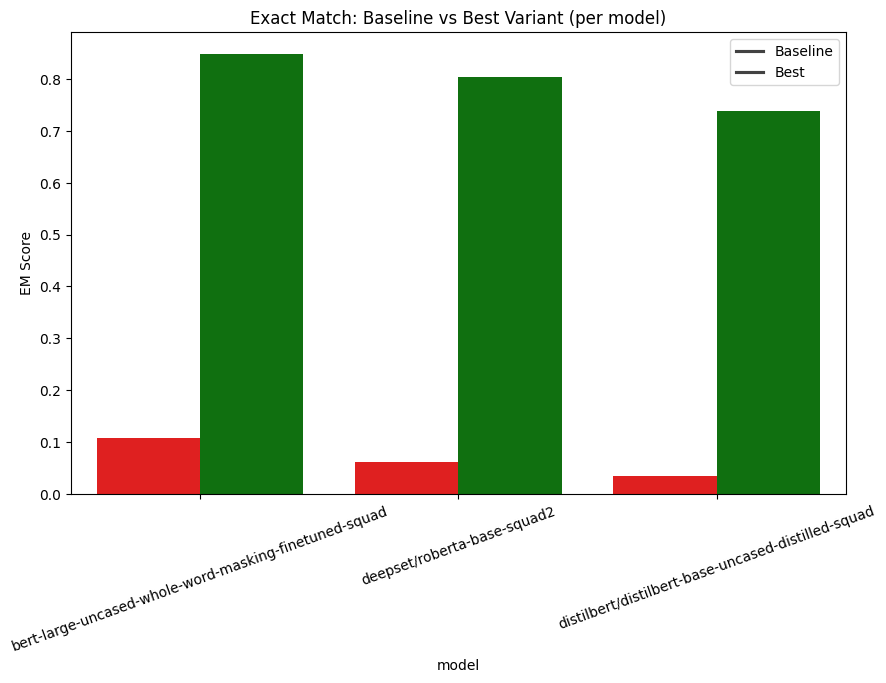

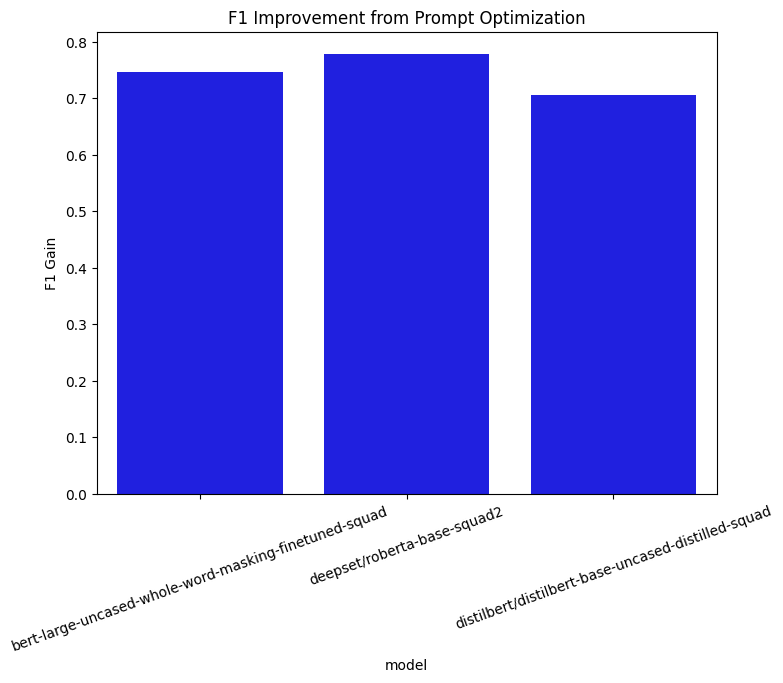

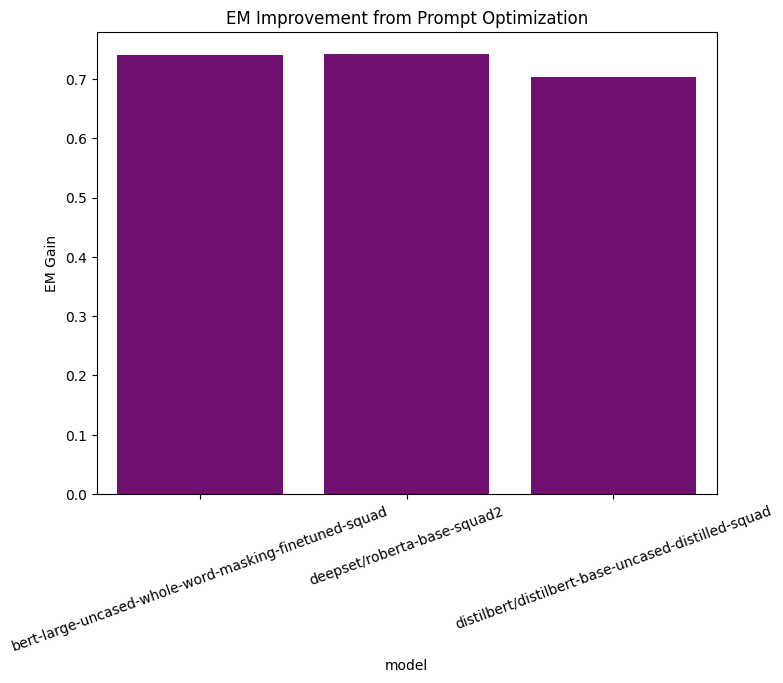

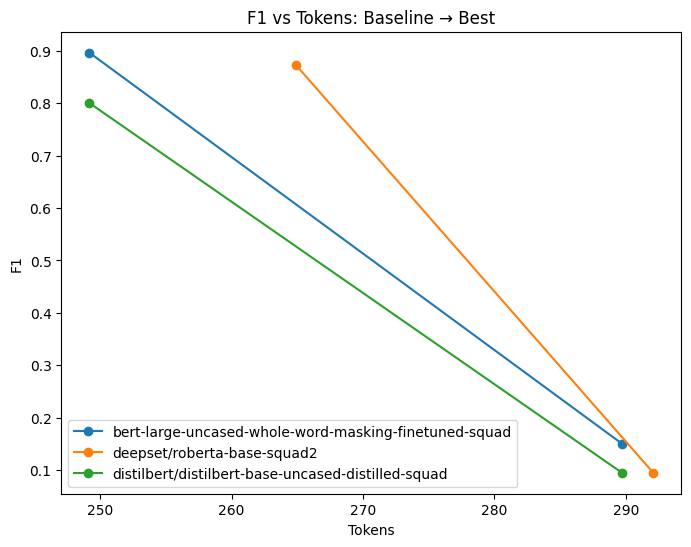

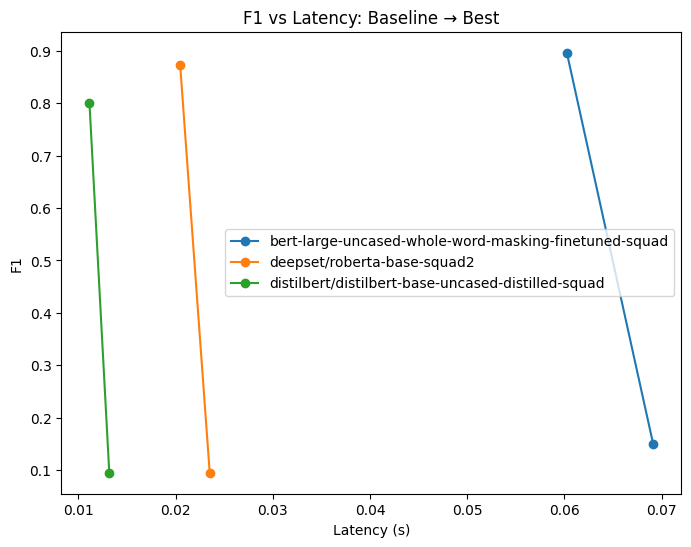

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load results file
df = pd.read_csv("phase4_results_fixed_variants_500.csv")  # change to 5000 later

# ---------------------------
# Compute per-model averages
# ---------------------------
model_variant_summary = df.groupby(["model","variant"])[["em","f1","latency","tokens"]].mean().reset_index()

# Extract baseline
baseline = model_variant_summary[model_variant_summary["variant"]=="baseline"]

# Best variant per model (highest F1)
best_variants = model_variant_summary.loc[model_variant_summary.groupby("model")["f1"].idxmax()]

# Merge into comparison table
comparison = baseline.merge(best_variants, on="model", suffixes=("_baseline","_best"))

# Compute improvements
comparison["f1_gain"] = comparison["f1_best"] - comparison["f1_baseline"]
comparison["em_gain"] = comparison["em_best"] - comparison["em_baseline"]

print("\n=== Baseline vs Best Variant (Per Model) ===\n")
print(comparison[["model","variant_baseline","variant_best",
                  "f1_baseline","f1_best","f1_gain",
                  "em_baseline","em_best","em_gain"]])

# ---------------------------
# Plot 1: F1 Baseline vs Best (side-by-side)
# ---------------------------
plt.figure(figsize=(10,6))
plot_df = pd.melt(comparison, id_vars=["model"],
                  value_vars=["f1_baseline","f1_best"],
                  var_name="type", value_name="F1")

sns.barplot(data=plot_df, x="model", y="F1", hue="type", palette=["red","green"])
plt.title("F1: Baseline vs Best Variant (per model)")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)
plt.legend(labels=["Baseline","Best"], title="")
plt.show()

# ---------------------------
# Plot 2: EM Baseline vs Best
# ---------------------------
plt.figure(figsize=(10,6))
plot_df = pd.melt(comparison, id_vars=["model"],
                  value_vars=["em_baseline","em_best"],
                  var_name="type", value_name="EM")

sns.barplot(data=plot_df, x="model", y="EM", hue="type", palette=["red","green"])
plt.title("Exact Match: Baseline vs Best Variant (per model)")
plt.ylabel("EM Score")
plt.xticks(rotation=20)
plt.legend(labels=["Baseline","Best"], title="")
plt.show()

# ---------------------------
# Plot 3: Gain (Delta plot)
# ---------------------------
plt.figure(figsize=(8,6))
sns.barplot(data=comparison, x="model", y="f1_gain", color="blue")
plt.title("F1 Improvement from Prompt Optimization")
plt.ylabel("F1 Gain")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8,6))
sns.barplot(data=comparison, x="model", y="em_gain", color="purple")
plt.title("EM Improvement from Prompt Optimization")
plt.ylabel("EM Gain")
plt.xticks(rotation=20)
plt.show()

# ---------------------------
# Plot 4: Tradeoff (F1 vs Tokens, Baseline vs Best)
# ---------------------------
plt.figure(figsize=(8,6))
for i, row in comparison.iterrows():
    plt.plot([row["tokens_baseline"], row["tokens_best"]],
             [row["f1_baseline"], row["f1_best"]],
             marker="o", label=row["model"])
plt.title("F1 vs Tokens: Baseline → Best")
plt.xlabel("Tokens")
plt.ylabel("F1")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
for i, row in comparison.iterrows():
    plt.plot([row["latency_baseline"], row["latency_best"]],
             [row["f1_baseline"], row["f1_best"]],
             marker="o", label=row["model"])
plt.title("F1 vs Latency: Baseline → Best")
plt.xlabel("Latency (s)")
plt.ylabel("F1")
plt.legend()
plt.show()


/tmp/ipython-input-2727885519.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x["f1"].idxmax()]["variant"])
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Classification Report (Prompt Ranker) ===

                      precision    recall  f1-score   support

            baseline       0.49      0.08      0.14       300
   context_highlight       0.75      0.80      0.77       300
explicit_instruction       0.46      0.82      0.59       300
          few_shot_3       0.81      0.80      0.80       300

            accuracy                           0.63      1200
           macro avg       0.63      0.63      0.58      1200
        weighted avg       0.63      0.63      0.58      1200

Accuracy: 0.6258333333333334


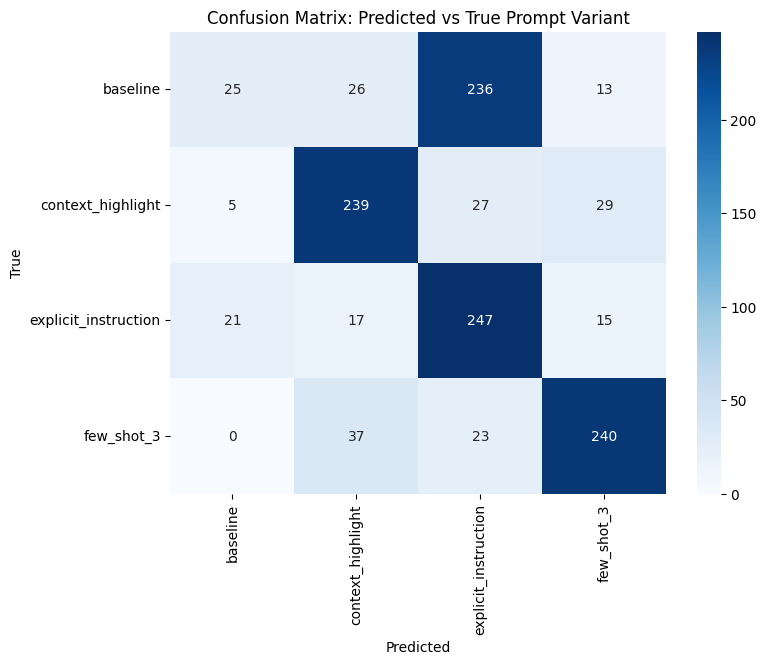


Demo prediction:
Best variant = context_highlight


In [33]:
# Phase 6: Prompt Ranker Training & Evaluation

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Load Phase 4 results
# ---------------------------
df = pd.read_csv("phase4_results_fixed_variants_500.csv")  # or 500 for testing

# ---------------------------
# 1. Build "best variant" labels
# ---------------------------
# For each sample+model, find which variant had the highest F1
# (We assume each row has a unique sample id in your dataset. If not, use index.)
df["sample_id"] = df.index // len(df["variant"].unique())  # crude grouping per sample

best_variant_per_sample = (
    df.groupby(["sample_id","model"])
    .apply(lambda x: x.loc[x["f1"].idxmax()]["variant"])
    .reset_index()
    .rename(columns={0:"best_variant"})
)

# Merge back with full dataframe
df = df.merge(best_variant_per_sample, on=["sample_id","model"], how="left")

# Add target: 1 if this row is the best variant, else 0
df["is_best"] = (df["variant"] == df["best_variant"]).astype(int)

# ---------------------------
# 2. Features for ranker
# ---------------------------
# Use numeric features + encodings
features = ["tokens","latency","em","f1"]  # base numeric features
X = df[features].values
y = df["variant"].values   # direct multi-class prediction of variant

# Encode target variants
label_enc = LabelEncoder()
y_enc = label_enc.fit_transform(y)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# 3. Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# ---------------------------
# 4. Train Logistic Regression ranker
# ---------------------------
clf = LogisticRegression(max_iter=200, multi_class="multinomial")
clf.fit(X_train, y_train)

# ---------------------------
# 5. Evaluate
# ---------------------------
y_pred = clf.predict(X_test)

print("\n=== Classification Report (Prompt Ranker) ===\n")
print(classification_report(y_test, y_pred, target_names=label_enc.classes_))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_)
plt.title("Confusion Matrix: Predicted vs True Prompt Variant")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---------------------------
# 6. Demo usage: Predict best variant for a new sample
# ---------------------------
def predict_best_variant(tokens, latency, em, f1):
    feat = scaler.transform([[tokens, latency, em, f1]])
    pred = clf.predict(feat)[0]
    return label_enc.inverse_transform([pred])[0]

print("\nDemo prediction:")
print("Best variant =", predict_best_variant(tokens=250, latency=0.02, em=0.5, f1=0.6))



=== Regression Evaluation ===
Mean Squared Error: 0.0981
R² Score: 0.5711


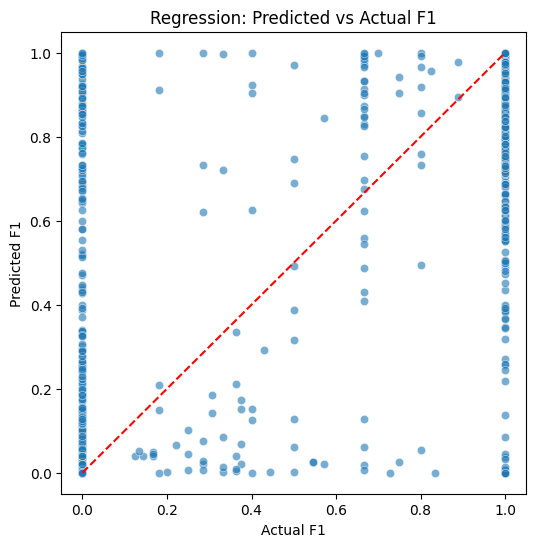


Demo Prediction:
Predicted F1 per variant = {'baseline': np.float64(0.012095959595959596), 'explicit_instruction': np.float64(0.03833333333333333), 'context_highlight': np.float64(0.9666666666666667), 'few_shot_3': np.float64(0.9288888888888891)}
Chosen best variant = context_highlight
✅ Ranker and encoders saved!


In [36]:
# Phase 7: Regression-based Prompt Ranker

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
# ---------------------------
# Load Phase 4 results
# ---------------------------
# Use whichever file you have (500 or 5000 samples)
df = pd.read_csv("phase4_results_fixed_variants_500.csv")

# ---------------------------
# Features and Target
# ---------------------------
# Basic features
df["question_len"] = df["tokens"] - df["tokens"].mean()  # rough proxy
df["context_len"] = df["tokens"]  # you can compute properly if context length available

features = ["tokens","latency","question_len","context_len"]
X = df[features].values
y = df["f1"].values   # target = actual F1 score

# Encode model + variant as categorical features
model_enc = LabelEncoder()
variant_enc = LabelEncoder()
df["model_enc"] = model_enc.fit_transform(df["model"])
df["variant_enc"] = variant_enc.fit_transform(df["variant"])

X = np.column_stack([X, df["model_enc"].values, df["variant_enc"].values])

# ---------------------------
# Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Train regression model
# ---------------------------
reg = RandomForestRegressor(n_estimators=150, random_state=42)
reg.fit(X_train, y_train)

# ---------------------------
# Evaluate
# ---------------------------
y_pred = reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Regression Evaluation ===")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot predicted vs actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([0,1],[0,1], color="red", linestyle="--")
plt.xlabel("Actual F1")
plt.ylabel("Predicted F1")
plt.title("Regression: Predicted vs Actual F1")
plt.show()

# ---------------------------
# Demo: Predict best variant for a new case
# ---------------------------
def predict_best_variant(tokens, latency, model_name, variants):
    preds = {}
    model_id = model_enc.transform([model_name])[0]
    for variant in variants:
        var_id = variant_enc.transform([variant])[0]
        q_len = tokens - df["tokens"].mean()
        c_len = tokens
        feat = np.array([[tokens, latency, q_len, c_len, model_id, var_id]])
        pred_f1 = reg.predict(feat)[0]
        preds[variant] = pred_f1
    best_variant = max(preds, key=preds.get)
    return best_variant, preds

# Example demo
variants = list(df["variant"].unique())
best, preds = predict_best_variant(
    tokens=250, latency=0.02, model_name="deepset/roberta-base-squad2", variants=variants
)

print("\nDemo Prediction:")
print("Predicted F1 per variant =", preds)
print("Chosen best variant =", best)


# Save everything needed for Phase 8
joblib.dump(reg, "prompt_ranker.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(model_enc, "model_encoder.pkl")
joblib.dump(variant_enc, "variant_encoder.pkl")

print("✅ Ranker and encoders saved!")


In [38]:
# Phase 8: End-to-End Prompt Optimization Demo (Fixed Feature Handling)

import time
import torch
import joblib
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline

# ---------------------------
# Load Trained Ranker + Encoders (from Phase 7)
# ---------------------------
reg = joblib.load("prompt_ranker.pkl")
scaler = joblib.load("scaler.pkl")
model_enc = joblib.load("model_encoder.pkl")
variant_enc = joblib.load("variant_encoder.pkl")

# ---------------------------
# Load QA Model
# ---------------------------
MODEL_NAME = "deepset/roberta-base-squad2"
print(f"Loading {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_NAME).to("cuda")
qa_pipeline = pipeline("question-answering", model=model, tokenizer=tokenizer, device=0)

# ---------------------------
# Prompt Variants Generator
# ---------------------------
def generate_variants(question, context):
    return {
        "baseline": question,
        "explicit_instruction": f"Please answer the following question based on the passage: {question}",
        "few_shot_3": (
            "Q: Who wrote Macbeth? A: William Shakespeare\n"
            "Q: Who developed calculus? A: Isaac Newton\n"
            f"Q: {question} A:"
        ),
        "context_highlight": (
            f"Focus only on this passage: '{context}'. "
            f"Question: {question}"
        )
    }

# ---------------------------
# Ranker Prediction (Fixed)
# ---------------------------
def predict_best_variant(question, context, model_name=MODEL_NAME):
    variants = generate_variants(question, context)
    preds = {}
    model_id = model_enc.transform([model_name])[0]

    for variant_name, prompt in variants.items():
        var_id = variant_enc.transform([variant_name])[0]

        # Extract numeric features
        tokens = len(tokenizer.tokenize(prompt + context))
        q_len = len(tokenizer.tokenize(prompt))
        c_len = len(tokenizer.tokenize(context))
        latency = 0.02  # placeholder avg

        # Scale only numeric
        numeric = [[tokens, latency, q_len, c_len]]
        numeric_scaled = scaler.transform(numeric)

        # Combine scaled numeric with raw categorical IDs
        feat = np.column_stack([numeric_scaled, [[model_id, var_id]]])

        # Predict F1
        pred_f1 = reg.predict(feat)[0]
        preds[variant_name] = pred_f1

    best_variant = max(preds, key=preds.get)
    return best_variant, preds, variants[best_variant]

# ---------------------------
# End-to-End Demo
# ---------------------------
def optimized_answer(question, context):
    best_variant, preds, chosen_prompt = predict_best_variant(question, context)

    print("\n=== Prompt Optimization Demo ===")
    print("Question:", question)
    print("Context:", context[:200], "..." if len(context)>200 else "")
    print("Predicted F1 scores per variant:", preds)
    print("Chosen best variant:", best_variant)

    # Run final QA
    out = qa_pipeline(question=chosen_prompt, context=context)
    print("\nFinal Answer:", out["answer"])
    return out["answer"]

# ---------------------------
# Test Demo
# ---------------------------
question = "Who developed the theory of relativity?"
context = "The theory of relativity was developed by Albert Einstein in the early 20th century."

optimized_answer(question, context)


Loading deepset/roberta-base-squad2 ...


Device set to use cuda:0



=== Prompt Optimization Demo ===
Question: Who developed the theory of relativity?
Context: The theory of relativity was developed by Albert Einstein in the early 20th century. 
Predicted F1 scores per variant: {'baseline': np.float64(0.1557946127946128), 'explicit_instruction': np.float64(0.3813894438894438), 'few_shot_3': np.float64(0.6735873015873015), 'context_highlight': np.float64(0.6675555555555555)}
Chosen best variant: few_shot_3

Final Answer: Albert Einstein


'Albert Einstein'